**Helpful Links**: 
- Covariance matrix of the multivariate normal distribution: https://statproofbook.github.io/P/mvn-cov.html
- Data, Covariance, and Correlation Matrix Slides: http://users.stat.umn.edu/~helwig/notes/datamat-Notes.pdf
- Covariance Matrix: https://en.wikipedia.org/wiki/Covariance_matrix
- Correlation Matrix: https://en.wikipedia.org/wiki/Correlation#Correlation_matrices

In [3]:
#> imports
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [125]:
#> num dimensions
d = 3
size = 10000

#> multivariate declarations
mu = np.zeros(shape=d)
cov = np.identity(n=d)
cov = cov*0.1 + 0.9
val = 0.1
off = 0.43588989537
print(off**2)
cov[0][1] = val
cov[1][0] = val
cov[0][2] = val - off
cov[2][0] = val - off
print(f'> The means are {mu}')
print(f'> The covariance matrix is :\n',cov)

cov = sample_psd_matrix(d)
print()
print(cov)
print()

#> drawing samples
samples = multivariate_normal.rvs(mean=mu, cov=cov, size=size, random_state=None)
print(samples)

0.19000000088566954
> The means are [0. 0. 0.]
> The covariance matrix is :
 [[ 1.         0.1       -0.3358899]
 [ 0.1        1.         0.9      ]
 [-0.3358899  0.9        1.       ]]
[[ 0.98374127  0.          0.        ]
 [ 0.29088506  6.09308242  0.        ]
 [-1.1609035  -0.55597451  0.04299034]]

[[ 0.96774688  0.28615563 -1.14202868]
 [ 0.28615563 37.2102675  -3.725288  ]
 [-1.14202868 -3.725288    1.65865276]]

[[ 0.0093044  -1.85643747  0.12656577]
 [-0.17868117 -2.92554815  0.45978319]
 [-0.16392529  3.85088468 -0.15060097]
 ...
 [ 0.35572323  5.1829848  -0.86807245]
 [-0.5156193   1.99242905  0.39444187]
 [ 0.38229523  4.01960342 -0.85759155]]


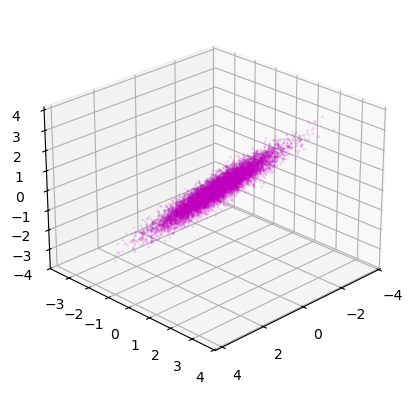

In [71]:
#> 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') 
ax.scatter(samples[:,0], samples[:,1], samples[:,2], s=1, alpha=0.1, c='m')
ax.view_init(elev=25, azim=45) # Set initial view

plt.show()

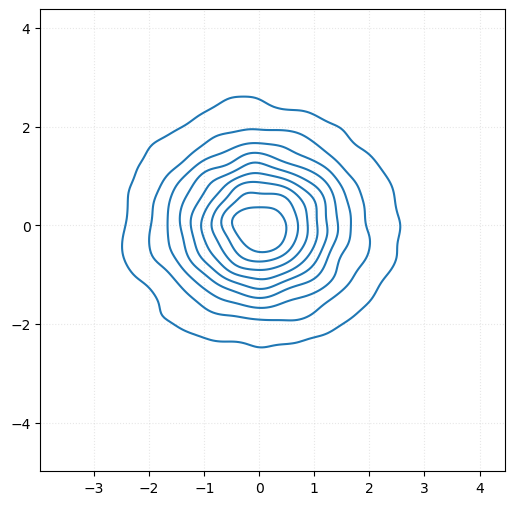

In [23]:
#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.grid(ls=':', alpha=0.3)

#> plotting!
sns.kdeplot(x=samples[:,0], y=samples[:,1])
# plt.plot(samples[:,0], samples[:,1])
plt.show()

## **Covariance Matrix**

The covariance matrix for 3 random variables is given by:
$$
\Sigma = \begin{bmatrix}
\sigma_1^2 & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_2^2 & \sigma_{23} \\
\sigma_{31} & \sigma_{32} & \sigma_3^2
\end{bmatrix} = \begin{bmatrix}
\sigma_{11} & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_{22} & \sigma_{23} \\
\sigma_{31} & \sigma_{32} & \sigma_{33}
\end{bmatrix}
$$

Variance of the $j$th variable is (diagonal):
$$
\sigma_j^2 = \sigma_{jj} = \frac{1}{n} \sum^n_{i=1} (x_{ij} - \overline{x}_j)^2
$$

The covariance between the $j$th and $k$th variables is (off-diagonal):
$$
\sigma_{jk} = \frac{1}{n} \sum^n_{i=1} (x_{ij} - \overline{x}_j) (x_{ik} - \overline{x}_k)
$$

And the mean of the $j$th variable is:
$$
\overline{x}_j = \frac{1}{n} \sum^n_{i=1} x_{ij}
$$

In [114]:
#> calculating the covariance matrix from data matrix

#> going through dimensions
covar = np.zeros(shape=(d,d))
for i in range(d):     # row
    for j in range(d): # column
        covar[i][j] = np.sum( (samples[:,i] - np.mean(samples[:,i])) * (samples[:,j] - np.mean(samples[:,j])) ) / len(samples)

#> calculating error
err_matrix = covar - cov
mae = np.mean( np.abs(err_matrix) )    # mean absolute error
mse = np.mean( np.square(err_matrix) ) # mean squared error
rms = np.sqrt( mse )

print(f'> The calculated covar matrix is:\n', covar)
print(f'> The true covar matrix is:\n', cov)
print(f'> The mean absolute error is: {mae:.1e}')
print(f'> The mean squared error is: {mse:.1e}')
print(f'> The root mean squared error (RMS) is: {rms:.1e}')

> The calculated covar matrix is:
 [[1.00493675 0.9040326 ]
 [0.9040326  1.00314621]]
> The true covar matrix is:
 [[1, 0.9], [0.9, 1]]
> The mean absolute error is: 4.0e-03
> The mean squared error is: 1.7e-05
> The root mean squared error (RMS) is: 4.1e-03


## **Correlation Matrix**

The correlation matrix for 3 random variables is given by:
$$
R = \begin{bmatrix}
1 & r_{12} & r_{13} \\
r_{21} & 1 & r_{23} \\
r_{31} & r_{32} & 1
\end{bmatrix}
$$

The pearson correlation between the $j$th and $k$th variables is:
$$
r_{jk} = \frac{\sigma_{jk}}{\sqrt{\sigma_{j}^2}\sqrt{\sigma_{k}^2}} = \frac{\sigma_{jk}}{\sqrt{\sigma_{jj}}\sqrt{\sigma_{kk}}} = \frac{\sum^n_{i=1} (x_{ij} - \overline{x}_j) (x_{ik} - \overline{x}_k)}{\sqrt{\sum^n_{i=1} (x_{ij} - \overline{x}_j)^2}\sqrt{\sum^n_{i=1} (x_{ik} - \overline{x}_k)^2}}
$$

The covariance matrix can be used to obtain the correlation matrix, and vice versa:
$$
R = \frac{\Sigma}{\sqrt{\sigma_j^2}\sqrt{\sigma_k^2}} = \frac{\Sigma}{\sqrt{\sigma_{jj}}\sqrt{\sigma_{kk}}} = \frac{1}{\sqrt{\sigma_{jj}}\sqrt{\sigma_{kk}}} \begin{bmatrix}
\sigma_{11} & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_{22} & \sigma_{23} \\
\sigma_{31} & \sigma_{32} & \sigma_{33}
\end{bmatrix} =
\begin{bmatrix}
\frac{\sigma_{11}}{\sqrt{\sigma_{11}}\sqrt{\sigma_{11}}} & \frac{\sigma_{12}}{\sqrt{\sigma_{11}}\sqrt{\sigma_{22}}} & \frac{\sigma_{13}}{\sqrt{\sigma_{11}}\sqrt{\sigma_{33}}} \\
\frac{\sigma_{21}}{\sqrt{\sigma_{22}}\sqrt{\sigma_{11}}} & \frac{\sigma_{22}}{\sqrt{\sigma_{22}}\sqrt{\sigma_{22}}} & \frac{\sigma_{23}}{\sqrt{\sigma_{22}}\sqrt{\sigma_{33}}} \\
\frac{\sigma_{31}}{\sqrt{\sigma_{33}}\sqrt{\sigma_{11}}} & \frac{\sigma_{32}}{\sqrt{\sigma_{33}}\sqrt{\sigma_{22}}} & \frac{\sigma_{33}}{\sqrt{\sigma_{33}}\sqrt{\sigma_{33}}} \\
\end{bmatrix} =
\begin{bmatrix}
1 & r_{12} & r_{13} \\
r_{21} & 1 & r_{23} \\
r_{31} & r_{32} & 1
\end{bmatrix}
$$

In [115]:
#> calculating the correlation matrix from data matrix

corr = np.zeros(shape=(d,d))
for i in range(d):
    for j in range(d):
        sigmaij = np.sum( (samples[:,i] - np.mean(samples[:,i])) * (samples[:,j] - np.mean(samples[:,j])) )
        sigmaii = np.sum( (samples[:,i] - np.mean(samples[:,i]))**2 )
        sigmajj = np.sum( (samples[:,j] - np.mean(samples[:,j]))**2 )
        corr[i][j] = sigmaij / ( np.sqrt(sigmaii) * np.sqrt(sigmajj) )
print(corr)

[[1.         0.90039404]
 [0.90039404 1.        ]]


In [117]:
#> calculating the correlation matrix from the covariance matrix

corr_cov = np.zeros(shape=(d,d))
for i in range(d):
    for j in range(d):
        corr_cov[i][j] = corr[i][j] / ( np.sqrt(corr[i][i]) * np.sqrt(corr[j][j]) ) 
print(corr_cov)

[[1.         0.90039404]
 [0.90039404 1.        ]]


### Multivariate MCMC
---

If the space of galaxy properties is given by a bivariate normal distribution then $x \sim N(\mu, \Sigma)$, where (for two arbitrary chosen parameters $q$ and $M$) the mean vector is given by $\mu = [ \overline{q}, \overline{M} ]$ and the correlation matrix: 
$\Sigma = \begin{bmatrix}
\sigma_q^2 & \sigma_{qM} \\
\sigma_{Mq} & \sigma_M^2
\end{bmatrix}
$, where $\sigma_{qM} \equiv \sigma_{Mq}$. 

---

To explore this bivariate normal space MCMC can be passed the vector: $\vec{\theta} = [\overline{q}, \overline{M}, \sigma_q^2, \sigma_M^2, \sigma_{qM}]$. 

---

After the MCMC has converged, the correlation matrix can be calculated from the covariance matrix: $R
= \frac{\Sigma}{\sqrt{\sigma_j^2}\sqrt{\sigma_k^2}}
= \begin{bmatrix}
\frac{\sigma_q^2}{\sigma_q^2} & \frac{\sigma_{qM}}{\sqrt{\sigma_q^2}\sqrt{\sigma_M^2}} \\
\frac{\sigma_{Mq}}{\sqrt{\sigma_M^2}\sqrt{\sigma_q^2}} & \frac{\sigma_M^2}{\sigma_M^2}
\end{bmatrix} = \begin{bmatrix}
1 & r_{qM} \\
r_{Mq} & 1
\end{bmatrix}
$, where $r_{qM} \equiv r_{Mq}$ and is the pearson correlation coefficient of the variables $q$ and $M$.

---

The total number of free params N as a function of the number of dimensions D is given by $N = \frac{D(D+3)}{2}$

In [123]:
for d in range(15):
    print(f'> N({d+1}) = {((d+1)*(d+4))/2:.0f}')

> N(1) = 2
> N(2) = 5
> N(3) = 9
> N(4) = 14
> N(5) = 20
> N(6) = 27
> N(7) = 35
> N(8) = 44
> N(9) = 54
> N(10) = 65
> N(11) = 77
> N(12) = 90
> N(13) = 104
> N(14) = 119
> N(15) = 135
